<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/GM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
### Zadanie 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import (KMeans , AgglomerativeClustering)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import (dendrogram , cut_tree)
!pip install ISLP
from ISLP.cluster import compute_linkage
from statsmodels.datasets import get_rdataset

In [6]:
### Zadanie 2
data= pd.read_csv("GD_dane_genetyczne.csv")
geny = data.iloc[:,0].tolist()
ekspresja = data.iloc[:,1:].to_numpy()
czas = data.columns[1:].to_numpy()
czas = list(map(float, czas))
#modyfikacja danych
np.random.seed(int(6.24*2026))
ekspresja = ekspresja + np.random.rand(614, 7) * 0.1 - 0.05

FileNotFoundError: [Errno 2] No such file or directory: 'GD_dane_genetyczne.csv'

In [ ]:
data

,-,0,9.5,11.5,13.5,15.5,18.5,20.5
0,SS DNA,-0.131,1.699,-0.026,0.365,-0.246,0.478,0.435
1,YAL003W,0.305,0.146,-0.129,-0.444,-0.707,-1.499,-1.935
2,YAL012W,0.157,0.175,0.467,-0.379,-0.520,-1.279,-2.125
3,YAL026C,0.246,0.796,0.384,0.981,1.020,1.646,1.157
4,YAL034C,-0.235,0.487,-0.184,-0.669,-1.006,2.369,2.611
...,...,...,...,...,...,...,...,...
609,YPR136C,0.158,-0.130,-0.880,-0.693,-1.020,-2.387,-1.009
610,YPR150W,-0.306,-0.446,-0.359,0.021,0.148,1.619,1.674
611,YPR156C,0.074,0.535,1.603,1.461,1.580,0.933,2.044
612,YPR184W,-0.195,0.165,-0.333,0.421,0.858,1.633,3.028


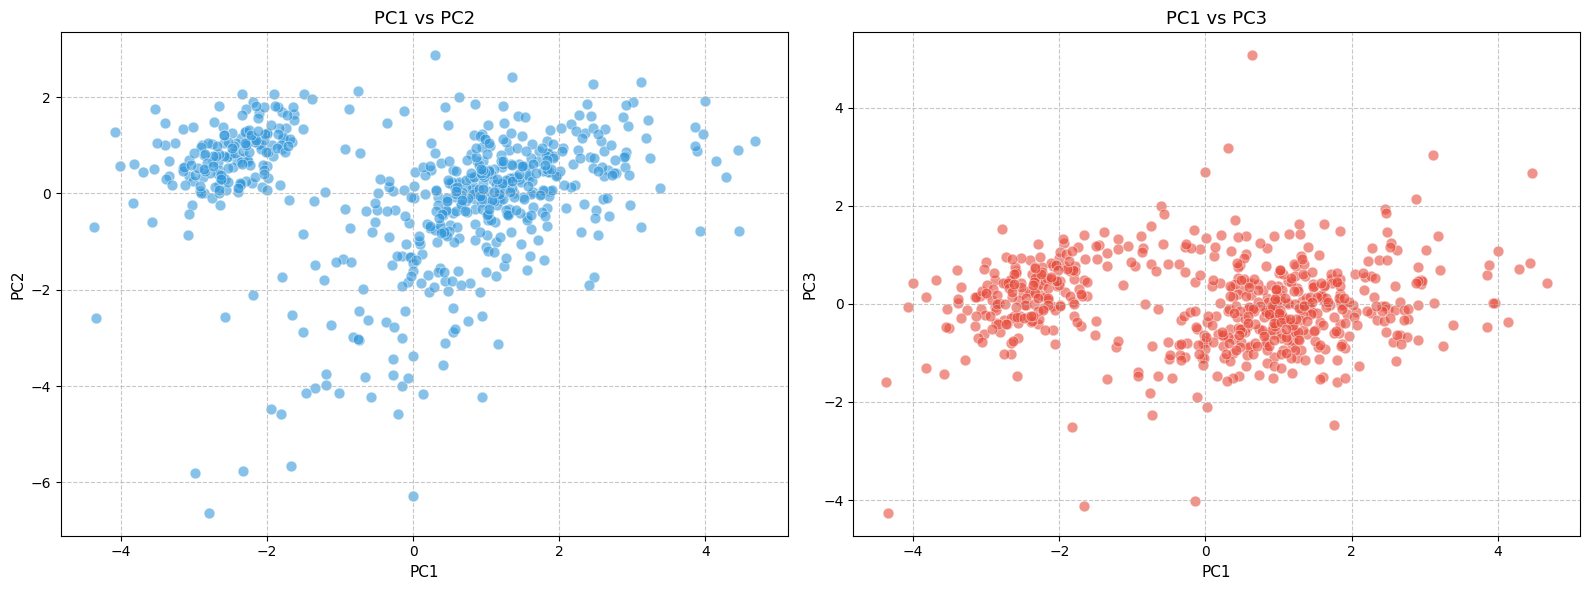

/tmp/ipykernel_3501/3040482693.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


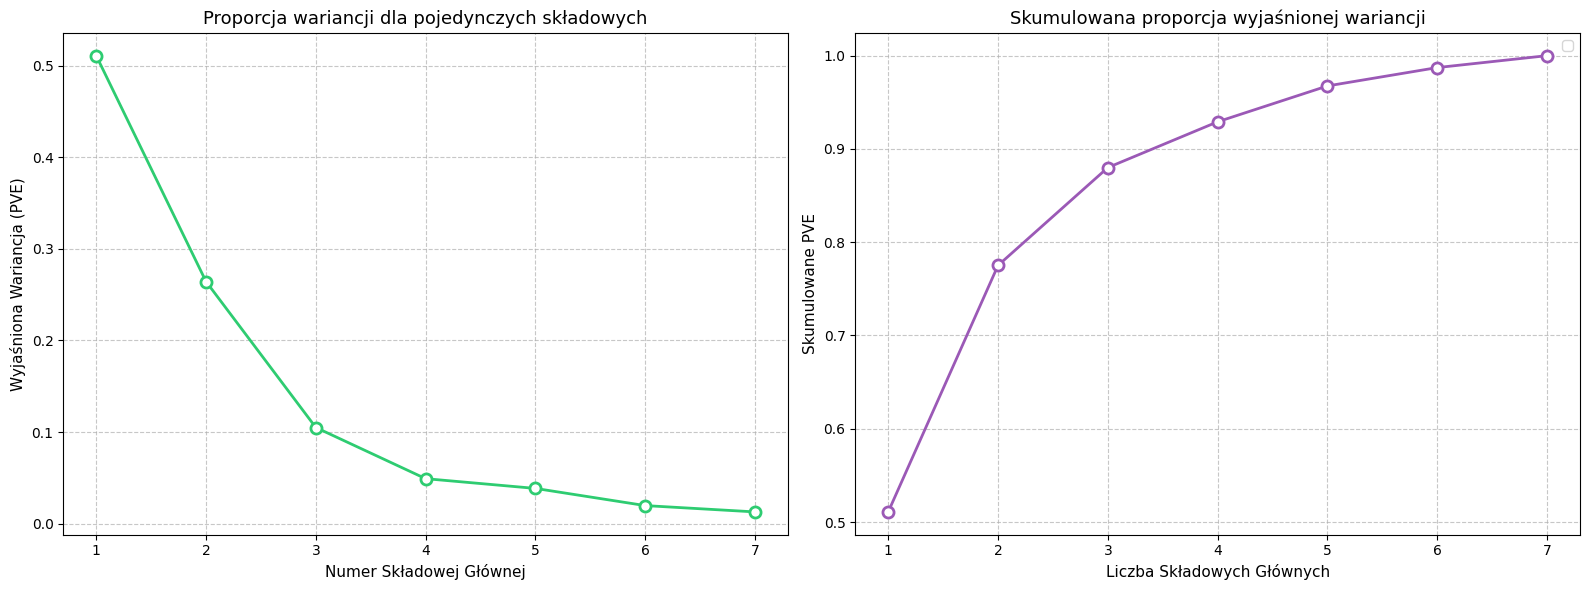

In [ ]:
### Zadanie 3
scaler = StandardScaler()
ekspresja_scaled = scaler.fit_transform(ekspresja)
pca = PCA()
scores = pca.fit_transform(ekspresja_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 vs PC2
ax = axes[0]
ax.scatter(scores[:,0], scores[:,1],
           c='#3498db',
           marker='o',
           s=60,
           alpha=0.6,
           edgecolors='white',
           linewidth=0.5)
ax.set_title('PC1 vs PC2', fontsize=13)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.7)

# PC1 vs PC3
ax = axes[1]
ax.scatter(scores[:,0], scores[:,2],
           c='#e74c3c',
           marker='o',
           s=60,
           alpha=0.6,
           edgecolors='white',
           linewidth=0.5)
ax.set_title('PC1 vs PC3', fontsize=13)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC3', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ticks = np.arange(pca.n_components_) + 1

ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_,
        marker='o', markersize=8, color='#2ecc71', linewidth=2, markerfacecolor='white', markeredgewidth=2)
ax.set_title('Proporcja wariancji dla pojedynczych składowych', fontsize=13)
ax.set_xlabel('Numer Składowej Głównej', fontsize=11)
ax.set_ylabel('Wyjaśniona Wariancja (PVE)', fontsize=11)
ax.set_xticks(ticks)
ax.grid(True, linestyle='--', alpha=0.7)

ax = axes[1]
ax.plot(ticks, pca.explained_variance_ratio_.cumsum(),
        marker='o', markersize=8, color='#9b59b6', linewidth=2, markerfacecolor='white', markeredgewidth=2)
ax.set_title('Skumulowana proporcja wyjaśnionej wariancji', fontsize=13)
ax.set_xlabel('Liczba Składowych Głównych', fontsize=11)
ax.set_ylabel('Skumulowane PVE', fontsize=11)
ax.set_xticks(ticks)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
### Zadanie 4
kmeans = KMeans(n_clusters=16, n_init=20, random_state=42)

kmeans.fit(ekspresja_scaled)

etykiety_kmeans = kmeans.labels_

print(etykiety_kmeans[:20])

[ 5 13  1  8  5  0  8  1  9  2  9  5 13  8  3  1  4  3  3  9]


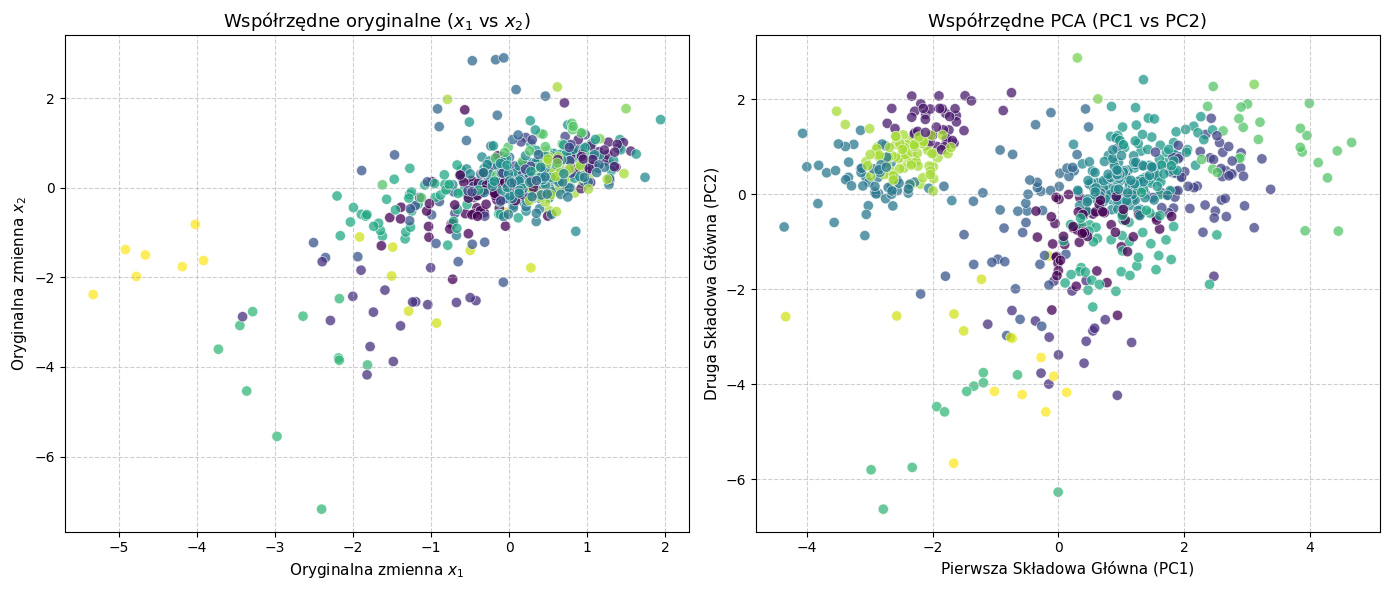

In [ ]:
### Zadanie 5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
scatter1 = ax.scatter(ekspresja_scaled[:, 0],
                      ekspresja_scaled[:, 1],
                      c=kmeans.labels_,
                      cmap='viridis',
                      marker='o',
                      s=55,
                      alpha=0.75,
                      edgecolors='white',
                      linewidth=0.5)

ax.set_title('Współrzędne oryginalne ($x_1$ vs $x_2$)', fontsize=13)
ax.set_xlabel('Oryginalna zmienna $x_1$', fontsize=11)
ax.set_ylabel('Oryginalna zmienna $x_2$', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

ax = axes[1]
scatter2 = ax.scatter(scores[:, 0],
                      scores[:, 1],
                      c=kmeans.labels_,
                      cmap='viridis',
                      marker='o',
                      s=55,
                      alpha=0.75,
                      edgecolors='white',
                      linewidth=0.5)

ax.set_title('Współrzędne PCA (PC1 vs PC2)', fontsize=13)
ax.set_xlabel('Pierwsza Składowa Główna (PC1)', fontsize=11)
ax.set_ylabel('Druga Składowa Główna (PC2)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()